# Шаблон моделирования эксперимента V–V

**Как пользоваться:** измените параметры в ячейке «Конфигурация» ниже и запустите все ячейки.

## Конфигурация

Измените только этот блок под свой эксперимент.

In [ ]:
# ── Частицы ──────────────────────────────────────────────
PARTICLE_A = "N2"   # имя частицы из particles/ (N2, O2, CO)
PARTICLE_B = "N2"

# ── Физика ───────────────────────────────────────────────
T_K = 300.0               # температура, K
V_MAX = 5                 # максимальная вибрационная модель
N_TOTAL = 2.45e19         # общая концентрация, см⁻³
F_V0 = 0.63               # доля молекул на v=0
F_V1 = 0.37               # доля молекул на v=1

# ── Интегрирование ───────────────────────────────────────
T_END_S = 12e-6           # конечное время, с
N_TIME = 600              # число точек по времени

# ── Диффузия ─────────────────────────────────────────────
# "none"              — без диффузии (ODE)
# "analytic_factor"   — аналитический коэффициент (ODE)
# "method_of_lines"   — метод линий (PDE → ODE система)
DIFFUSION_METHOD = "analytic_factor"
SIGMA_PUMP_CM = 46e-4    # диаметр накачки, см
SIGMA_PROBE_CM = 46e-4   # диаметр зонда, см
D_REF = 0.25              # D₀, см²/с (при p_torr)
P_TORR = 760.0            # давление, торр

# ── Сетка (только для method_of_lines) ───────────────────
R_MAX_CM = 200e-4         # максимальный радиус, см
N_R = 80                  # число узлов по r

# ── Кинетика ─────────────────────────────────────────────
# "regression"     — коэффициенты регрессии из CSV
# "fhofer"         — аналитическая формула FHO-FR
KINETICS = "regression"
RATE_MULTIPLIER = 1     # множитель k_VV

# ── CSV с коэффициентами (опционально) ───────────────────
# Если None → берётся {PARTICLE_A}_{PARTICLE_B}_regression_coefs.csv
# Можно указать полный путь или имя файла в base_dir
REGRESSION_CSV = None

# ── Эксперимент (опционально) ────────────────────────────
# experiment_key — данные из experiments/registry.py
# Доступные: ("N2","N2",760), ("N2","N2",300), ("O2","O2",760)
EXPERIMENT_KEY = ("N2", "N2", 760)   # или None для ручной настройки

# ── Дополнительные прогоны (опционально) ─────────────────
# Список dict с параметрами для переопределения в ModelingConfig.
# Оставьте пустым для одного прогона.
EXTRA_RUNS = []
# Доступные ключи: name, particle_a, particle_b, kinetics,
#   rate_multiplier, regression_csv, T, v_max, n_total, f_v0, f_v1,
#   t_end_s, n_time, diffusion_method, sigma_pump_cm, sigma_probe_cm,
#   d_ref, p_torr, r_max_cm, n_r, experiment_key,
#   exp_ye_by_v, exp_dots_inline, exp_csv_styles

## Запуск

In [ ]:
from vv_modeling import ModelingConfig, ModelingBatch

base_cfg = dict(
    particle_a=PARTICLE_A,
    particle_b=PARTICLE_B,
    kinetics=KINETICS,
    rate_multiplier=RATE_MULTIPLIER,
    regression_csv=REGRESSION_CSV,
    T=T_K,
    v_max=V_MAX,
    n_total=N_TOTAL,
    f_v0=F_V0,
    f_v1=F_V1,
    t_end_s=T_END_S,
    n_time=N_TIME,
    diffusion_method=DIFFUSION_METHOD,
    sigma_pump_cm=SIGMA_PUMP_CM,
    sigma_probe_cm=SIGMA_PROBE_CM,
    d_ref=D_REF,
    p_torr=P_TORR,
    r_max_cm=R_MAX_CM,
    n_r=N_R,
    experiment_key=EXPERIMENT_KEY,
)

configs = [
    ModelingConfig(name="baseline", **base_cfg),
    *[ModelingConfig(name=r.pop("name", f"run_{i}"), **{**base_cfg, **r})
      for i, r in enumerate(EXTRA_RUNS, 1)],
]

batch = ModelingBatch(configs)
batch.run_all(max_workers=10)

from vv_plotting import completed_run_labels
print("done:", ", ".join(completed_run_labels(batch)))

## Графики заселённостей

In [ ]:
import matplotlib.pyplot as plt

from vv_plotting import (
    PopulationPlotConfig,
    plot_population_grid,
    completed_run_labels,
)

PLOT = PopulationPlotConfig(
    diffusion_per_run=True,     # True — отдельная колонка на диффузию
    max_v_plots=V_MAX + 1,      # макс. число графиков (v=0…v_max)
    ncols=3,                    # число колонок в сетке
    # t_max_us_by_v={0: 2.0, 1: 5.0},  # ограничение по оси x для каждого v
    # show_experiment=False,     # скрыть экспериментальные точки
    # show_article_fho=False,    # скрыть FHO-FR (статья)
    # show_exp_csv_styles=False, # скрыть CSV стили
)

print("На графике:", ", ".join(completed_run_labels(batch)))

fig, axes = plot_population_grid(batch, plot_cfg=PLOT)
plt.show()

## Сравнение k_VV

In [ ]:
# from vv_plotting import plot_k_vv_comparison

# # Автоматически берём article данные из registry (если experiment_key задан)
# _art_x, _art_y = None, None
# _art_label = "Статья"
# if EXPERIMENT_KEY is not None:
#     from experiments.registry import get_experiment
#     _exp = get_experiment(*EXPERIMENT_KEY)
#     if "k_vv_article" in _exp:
#         _art_x, _art_y = _exp["k_vv_article"]
#         _art_label = f"k_VV (статья, {EXPERIMENT_KEY[0]}–{EXPERIMENT_KEY[1]}, {EXPERIMENT_KEY[2]} Torr)"

# fig, ax = plot_k_vv_comparison(
#     batch.run_at(0),
#     article_x=_art_x,
#     article_y=_art_y,
#     article_label=_art_label,
#     v_range=(1, V_MAX + 1),
# )
# plt.show()

## Моделирование O₂–O₂ (Ahn & Adamovich)

In [33]:
# ── Частицы ──────────────────────────────────────────────
O2_PARTICLE_A = "O2"
O2_PARTICLE_B = "O2"

# ── Физика ───────────────────────────────────────────────
O2_T_K = 300.0
O2_V_MAX = 6
O2_N_TOTAL = 5.14e18
O2_F_V0 = 0.63
O2_F_V1 = 0.37

# ── Интегрирование ───────────────────────────────────────
O2_T_END_S = 12e-6
O2_N_TIME = 600

# ── Диффузия ─────────────────────────────────────────────
O2_DIFFUSION_METHOD = "analytic_factor"
O2_SIGMA_PUMP_CM = 80e-4
O2_SIGMA_PROBE_CM = 40e-4
O2_D_REF = 0.2
O2_P_TORR = 760.0

# ── Сетка ───────────────────────────────────────────────
O2_R_MAX_CM = 200e-4
O2_N_R = 80

# ── Кинетика ─────────────────────────────────────────────
O2_KINETICS = "regression"
O2_RATE_MULTIPLIER = 1.0
O2_REGRESSION_CSV = None

# ── Эксперимент ──────────────────────────────────────────
O2_EXPERIMENT_KEY = ("O2", "O2", 760)

# ── Дополнительные прогоны ───────────────────────────────
O2_EXTRA_RUNS = [
    {"name": "O₂–O₂ (×8.0)", "rate_multiplier": 8.0},

    {"name": "O₂–O₂ (×8.0), метод линий", "rate_multiplier": 8.0, "diffusion_method": "method_of_lines"},

    # {"name": "O₂–O₂ (×8.0), метод линий, r_max_cm=200e-4",
    #  "rate_multiplier": 8.0,
    #  "diffusion_method": "method_of_lines",
    #  "r_max_cm": 100e-4,
    #  },
]

In [34]:
o2_base_cfg = dict(
    particle_a=O2_PARTICLE_A,
    particle_b=O2_PARTICLE_B,
    kinetics=O2_KINETICS,
    rate_multiplier=O2_RATE_MULTIPLIER,
    regression_csv=O2_REGRESSION_CSV,
    T=O2_T_K,
    v_max=O2_V_MAX,
    n_total=O2_N_TOTAL,
    f_v0=O2_F_V0,
    f_v1=O2_F_V1,
    t_end_s=O2_T_END_S,
    n_time=O2_N_TIME,
    diffusion_method=O2_DIFFUSION_METHOD,
    sigma_pump_cm=O2_SIGMA_PUMP_CM,
    sigma_probe_cm=O2_SIGMA_PROBE_CM,
    d_ref=O2_D_REF,
    p_torr=O2_P_TORR,
    r_max_cm=O2_R_MAX_CM,
    n_r=O2_N_R,
    experiment_key=O2_EXPERIMENT_KEY,
)

o2_configs = [
    ModelingConfig(name="O₂–O₂ (×1.0)", **o2_base_cfg),
    *[ModelingConfig(name=r.pop("name", f"o2_run_{i}"), **{**o2_base_cfg, **r})
      for i, r in enumerate(O2_EXTRA_RUNS, 1)],
]

o2_batch = ModelingBatch(o2_configs)
o2_batch.run_all(max_workers=10, styles=("solid",))

from vv_plotting import completed_run_labels
print("done:", ", ".join(completed_run_labels(o2_batch)))

k_VV: O2_O2_regression_coefs.csv (72 переходов)
k_VV: O2_O2_regression_coefs.csv (72 переходов)
k_VV: O2_O2_regression_coefs.csv (72 переходов)
Предупреждение: solid/v6solid.csv не найден
Предупреждение: solid/v6solid.csv не найден
Предупреждение: dashed/v6dashed.csv не найден
Предупреждение: dashed/v6dashed.csv не найден
Предупреждение: fhov0.csv не найден
Предупреждение: fhov0.csv не найден
Предупреждение: fhov1.csv не найден
Предупреждение: fhov1.csv не найден
Предупреждение: fhov2.csv не найден
Предупреждение: fhov2.csv не найден
Предупреждение: fhov3.csv не найден
Предупреждение: fhov3.csv не найден
Предупреждение: fhov4.csv не найден
Предупреждение: fhov4.csv не найден
Предупреждение: fhov5.csv не найден
Предупреждение: fhov5.csv не найден
Предупреждение: fhov6.csv не найден
Предупреждение: fhov6.csv не найден
  готово: O₂–O₂ (×8.0)::analytic_factor
  готово: O₂–O₂ (×1.0)::analytic_factor
Предупреждение: solid/v6solid.csv не найден
Предупреждение: dashed/v6dashed.csv не найден
Пр

На графике: O₂–O₂ (×1.0), O₂–O₂ (×8.0), O₂–O₂ (×8.0), метод линий


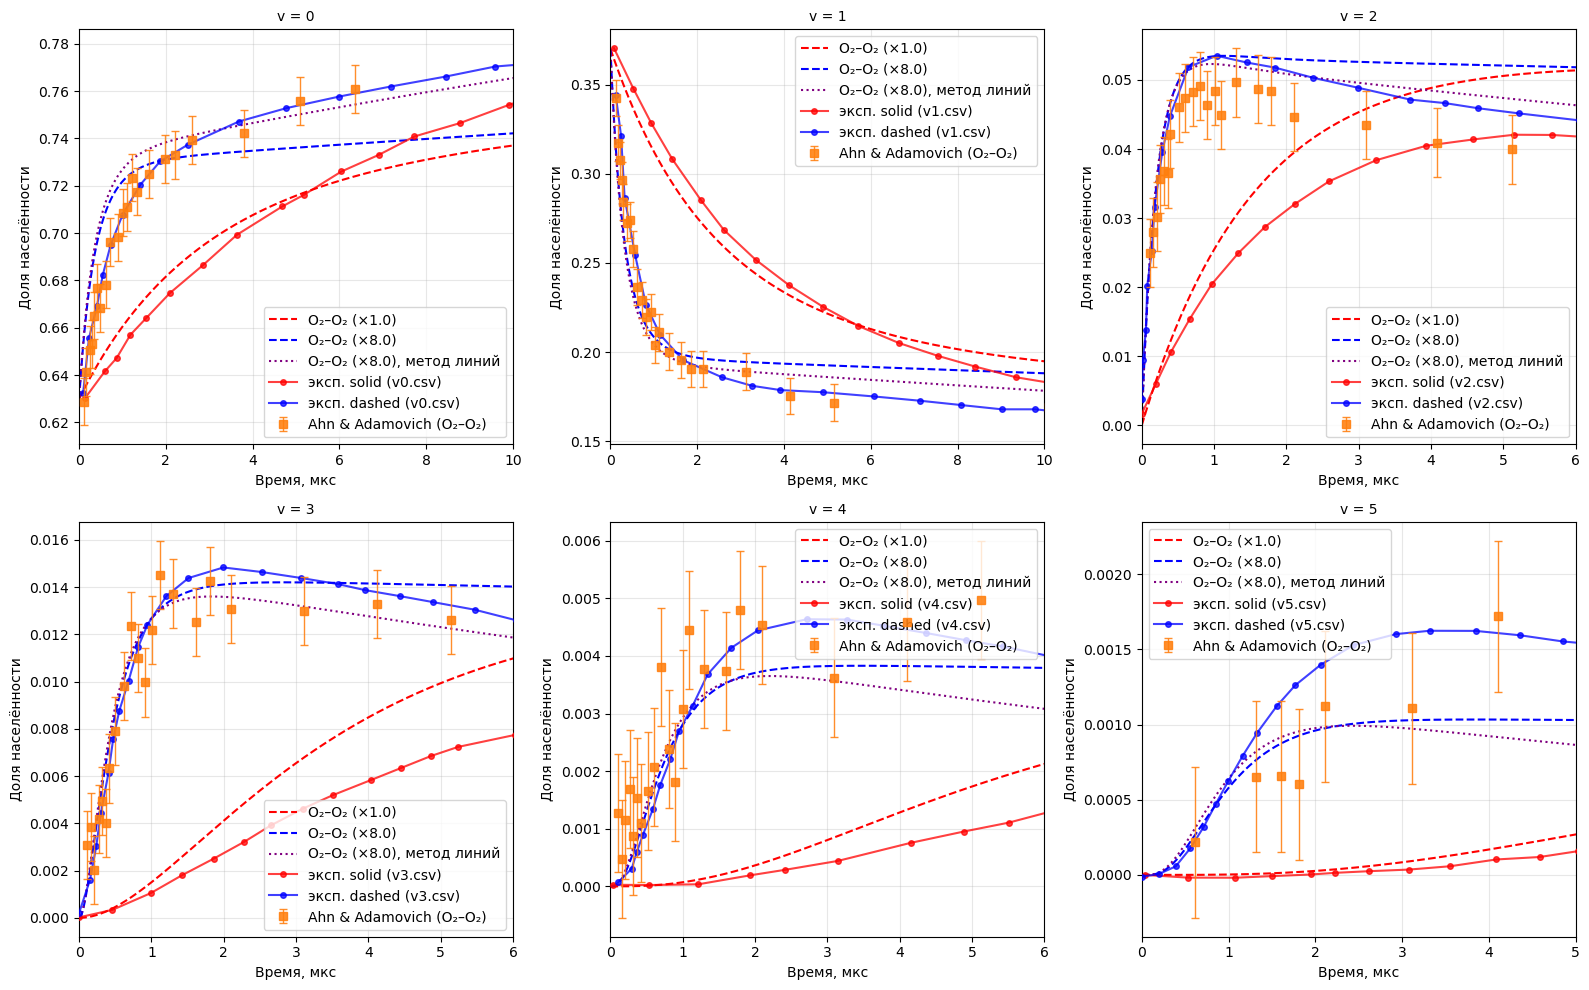

In [35]:
from vv_plotting import (
    PopulationPlotConfig,
    plot_population_grid,
    completed_run_labels,
)
import matplotlib.pyplot as plt

O2_PLOT = PopulationPlotConfig(
    diffusion_per_run=True,
    plot_styles={"solid": {"color": "red"}, "dashed": {"color": "blue"}},
    exp_csv_colors={"solid": "red", "dashed": "blue"},
    legend_exp_dots="Ahn & Adamovich (O₂–O₂)",
    show_article_fho=False,
    max_v_plots=6,
    t_max_us_by_v=(10, 10, 6, 6, 6, 5),
)

print("На графике:", ", ".join(completed_run_labels(o2_batch)))

fig, axes = plot_population_grid(o2_batch, plot_cfg=O2_PLOT)
plt.show()